In [33]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Criação dos datasets

In [34]:
cloud_df = pd.read_csv("influx.csv", index_col=0)
cloud_df.rename(columns={'timestamp': 'alert_detection', 'time': 'influx_arrival'}, inplace=True)
cloud_df.index = range(0, cloud_df.shape[0])

cloud_df

,event_id,alert_detection,influx_arrival
0,5905b567-a113-43ed-ad11-9f037d4516a7,2025-11-04T02:56:19.854367,2025-11-04T02:56:20.354424891Z
1,7e3aba8d-f909-4bb5-8185-ff169732e1e8,2025-11-04T02:56:20.848045,2025-11-04T02:56:21.844296874Z
2,4302b9c9-82f1-476b-89f4-22c31620da56,2025-11-04T02:56:21.848269,2025-11-04T02:56:22.085837604Z
3,67771f46-948d-4212-acb4-ac7d2c68146f,2025-11-04T02:56:22.855412,2025-11-04T02:56:23.322443324Z
4,85b40848-614e-4053-8285-cda1af104a0a,2025-11-04T02:56:23.849873,2025-11-04T02:56:24.49381124Z
...,...,...,...
2138,1e2fac39-65e0-4b20-8647-1263d2000b71,2025-11-04T02:56:15.606881,2025-11-04T02:56:15.973780445Z
2139,61bf8b32-4ff6-4b7b-afde-ca70e98f29e6,2025-11-04T02:56:16.601175,2025-11-04T02:56:17.89618197Z
2140,afcc5686-efb7-4c9c-a63e-79a60721a157,2025-11-04T02:56:17.603974,2025-11-04T02:56:18.202401241Z
2141,022b2faf-e000-4228-bfa0-5921fe12594b,2025-11-04T02:56:18.599860,2025-11-04T02:56:19.127916837Z


In [39]:
events_df = pd.read_json("../../logs/events_4_engines", lines=True)[["event_id", "timestamp"]]
join = pd.merge(events_df, cloud_df, how="inner", on="event_id")
join = join.rename({"timestamp": "event_generation"})

join["local_detection_time_ms"] = (
        (pd.to_datetime(join['alert_detection']) - pd.to_datetime(join['timestamp']))
        .dt.total_seconds() * 1000
        )

join["latency_detection_to_influx_ms"] = (
        (pd.to_datetime(join['influx_arrival']) - pd.to_datetime(join['alert_detection'], utc=True))
        .dt.total_seconds() * 1000
        )

join["latency_e2e_ms"] = (
        (pd.to_datetime(join['influx_arrival']) - pd.to_datetime(join['timestamp'], utc=True))
        .dt.total_seconds() * 1000
        )

join = join[["event_id", "local_detection_time_ms", "latency_detection_to_influx_ms", "latency_e2e_ms"]]
join.head()

,event_id,local_detection_time_ms,latency_detection_to_influx_ms,latency_e2e_ms
0,82a39f69-b57e-4317-b13f-b3767e70e78b,23.462,248.268236,271.730236
1,5de0fb2e-30c0-4bb2-af60-e680aa458eeb,34.416,276.441367,310.857367
2,222c6435-b293-4d44-b24f-1aa8867bc5ca,26.444,272.287785,298.731785
3,7a8ace72-9f4e-45a4-87a8-e1cb199b9ec7,26.215,296.327276,322.542276
4,19f302d3-dae5-479a-aafd-1c20a654f78f,27.083,283.704905,310.787905


# Análise Estatística

In [40]:
stats = join.describe()
stats

,local_detection_time_ms,latency_detection_to_influx_ms,latency_e2e_ms
count,2143.000000,2143.000000,2143.000000
mean,28.992914,457.110164,486.103077
std,9.936764,234.387058,234.254687
min,14.404000,236.806029,253.267838
25%,23.306000,326.782426,355.858269
50%,27.287000,401.075715,430.878307
75%,33.112500,484.090934,513.972025
max,135.385000,2470.703990,2498.922990


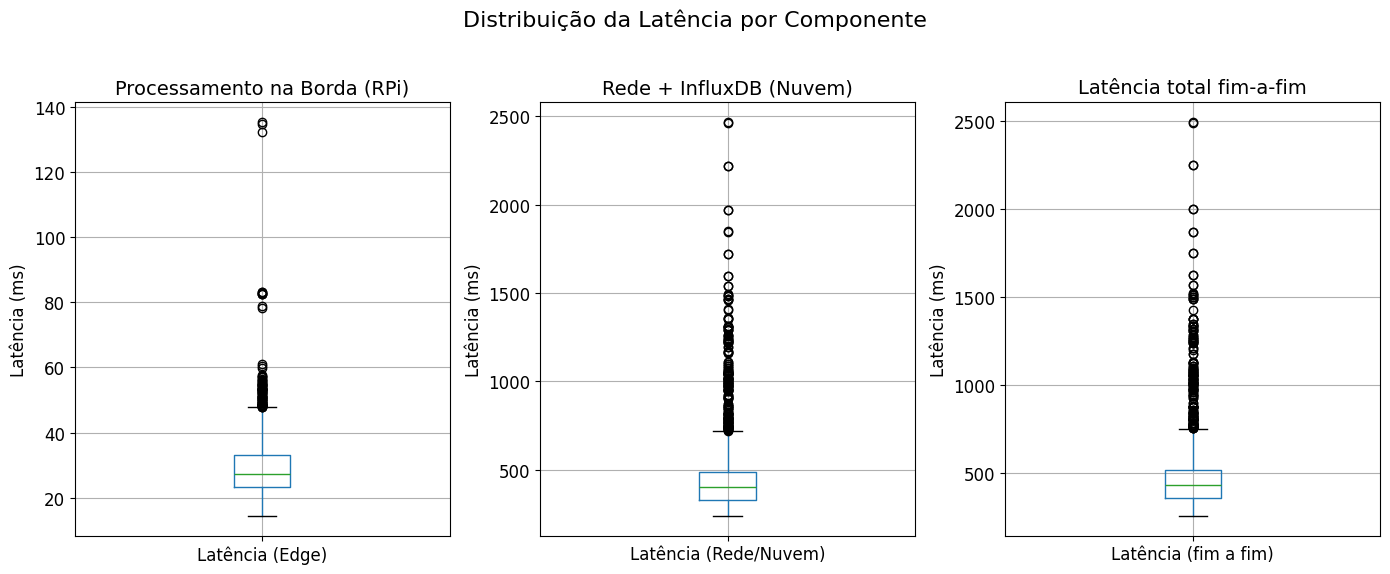

In [42]:
df_renamed = join.rename(columns={
'latency_e2e_ms': 'Latência (fim a fim)',
'local_detection_time_ms': 'Latência (Edge)',
'latency_detection_to_influx_ms': 'Latência (Rede/Nuvem)',
})

# Cria uma figura com 1 linha e 2 colunas de gráficos
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

fig.suptitle('Distribuição da Latência por Componente', fontsize=16)

# Gráfico da Esquerda (Edge)
df_renamed.boxplot(
        column=['Latência (Edge)'],
        ax=axes[0], # Plota no primeiro eixo
        grid=True,
        fontsize=12
)
axes[0].set_ylabel('Latência (ms)', fontsize=12)
axes[0].set_title('Processamento na Borda (RPi)', fontsize=14)

# Gráfico da Direita (Cloud)
df_renamed.boxplot(
        column=['Latência (Rede/Nuvem)'],
        ax=axes[1], # Plota no segundo eixo
        grid=True,
        fontsize=12
)

axes[1].set_ylabel('Latência (ms)', fontsize=12)
axes[1].set_title('Rede + InfluxDB (Nuvem)', fontsize=14)

# Gráfico da Direita (Cloud)
df_renamed.boxplot(
        column=['Latência (fim a fim)'],
        ax=axes[2], # Plota no segundo eixo
        grid=True,
        fontsize=12
)

axes[2].set_ylabel('Latência (ms)', fontsize=12)
axes[2].set_title('Latência total fim-a-fim', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta para o título

Text(0.985, 0.85, 'amostras = 2143')

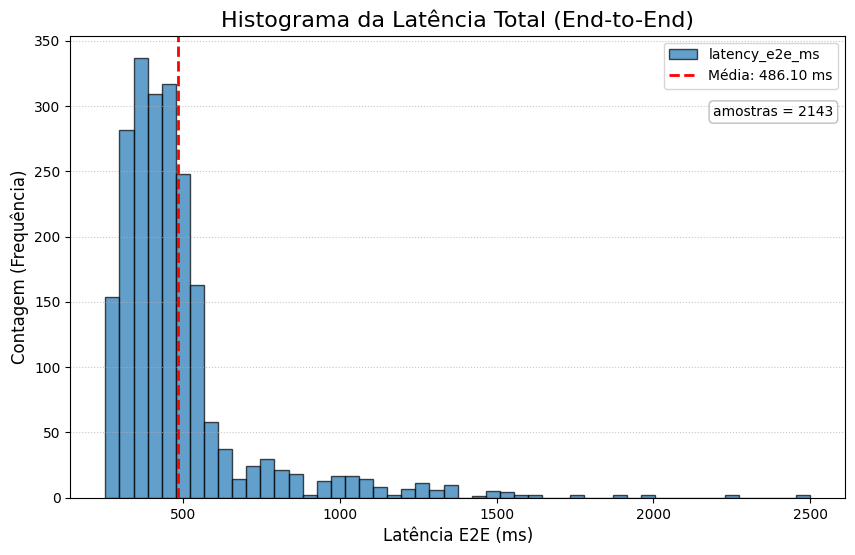

In [71]:
plt.figure(figsize=(10, 6))

# --- INÍCIO DA MODIFICAÇÃO ---
# Pega o eixo atual (axis) para poder adicionar texto
ax = plt.gca()
# --- FIM DA MODIFICAÇÃO ---

join['latency_e2e_ms'].plot(kind='hist', bins=50, ec='black', alpha=0.7, ax=ax) # Passa 'ax'

mean_e2e = stats.loc['mean', 'latency_e2e_ms']
plt.axvline(mean_e2e, color='red', linestyle='--', linewidth=2,
        label=f"Média: {mean_e2e:.2f} ms")

# --- INÍCIO DA MODIFICAÇÃO ---
# Pega o tamanho da amostra (N) do dataframe de estatísticas
sample_size = stats.loc['count', 'latency_e2e_ms']
plt.title('Histograma da Latência Total (End-to-End)', fontsize=16)

plt.xlabel('Latência E2E (ms)', fontsize=12)

plt.ylabel('Contagem (Frequência)', fontsize=12)

plt.legend()

plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.text(0.985, 0.85, f'amostras = {int(sample_size)}', # Posição Y ajustada
             horizontalalignment='right',
             verticalalignment='top',
             transform=ax.transAxes,
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.5))